In [2]:
import os
import shutil
import getpass
#from google.colab import drive
from PIL import Image
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
import torch
import torchvision
from torchvision import transforms
import torchvision.models
import torch.nn as nn
import torch.nn.functional as F  # needed for supcon math because reliant on cosine similarity so F.normalize needed to project 
#plastic features onto hyperspace so model can group PET together and push other RIC#'s away'
import torch.optim as optim      # For the AdamW optimizer
from torchvision.models import swin_b, Swin_B_Weights # Specific Swin-B access

In [2]:
!python --version

Python 3.10.12


In [3]:
!nvidia-smi

Wed Apr  8 13:09:47 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla V100-SXM2-16GB           On  |   00000000:18:00.0 Off |                    0 |
| N/A   40C    P0             43W /  300W |       0MiB /  16384MiB |      0%   E. Process |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [7]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2022 NVIDIA Corporation
Built on Wed_Sep_21_10:33:58_PDT_2022
Cuda compilation tools, release 11.8, V11.8.89
Build cuda_11.8.r11.8/compiler.31833905_0


In [5]:
torch.version.cuda

'12.8'

In [3]:
# using absolute path to data
local_path = "/projectnb/ec523/projects/finalProjectPlastic/0_Data/wadaba_local"

BATCH_SIZE = 2

In [4]:
#!source plasticEnv_2/bin/activate

In [4]:
#NOTE on plasticEnv environment
#I created a python virtual environment and followed this tutorial: https://www.w3schools.com/python/python_virtualenv.asp
#This idea of creating a python virtual environment came from Connor Casey https://piazza.com/class/mkcrybcxyxq2ep/post/56



In [ ]:
# setting up pathways
#drive_zip_folder = "/content/drive/MyDrive/Spring 2026/Deep Learning/Deep Learning Project/Wadaba Dataset/"
#local_path = "/content/wadaba_local"

#ben's directories
#drive_zip_folder = "/content/drive/MyDrive/Deep Learning Project/Wadaba Dataset/"
#local_path = "/content/drive/MyDrive/wadaba_local"

if os.path.exists("/content/drive/MyDrive/Deep Learning Project"):
  user = "Dani"
  drive_zip_folder = "/content/drive/MyDrive/Deep Learning Project/Wadaba Dataset/"

elif os.path.exists("/content/drive/MyDrive/Deep Learning Project"):
  user = "Ben"
  drive_zip_folder = "/content/drive/MyDrive/Deep Learning Project/Wadaba Dataset/"

else:
  user = "James"
  drive_zip_folder = "/content/drive/MyDrive/Deep Learning Project/Wadaba Dataset/" #put your path here

local_path = "/content/wadaba_local"

if os.path.exists(local_path) and len([f for f in os.listdir(local_path) if f.endswith(('.jpg', '.png'))]) > 4000:
    print(f"The images are already present in local SSD. Skipping unzip.")
else:
    print(f"Hi {user}!")
    pwd = getpass.getpass('Enter WaDaBa Zip Password: ')
    os.makedirs(local_path, exist_ok=True)

    # Extracting
    print("Extracting files... please wait.")
    !cd "{drive_zip_folder}" && unzip -P "{pwd}" -qo "*.zip" -d "{local_path}"

    print("Flattening subfolders...")
    for root, dirs, files in os.walk(local_path):
        if root == local_path: continue
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                shutil.move(os.path.join(root, file), os.path.join(local_path, file))

    # discarding empty folders
    for item in os.listdir(local_path):
        item_path = os.path.join(local_path, item)
        if os.path.isdir(item_path):
            shutil.rmtree(item_path)

all_images = [f for f in os.listdir(local_path) if f.lower().endswith(('.jpg', '.png'))]

Hi Dani!
Enter WaDaBa Zip Password: ··········
Extracting files... please wait.
Flattening subfolders...


In [15]:
#class to go through files, splice labels and map to RIC for Pytorch tensors
class WadabaData(Dataset):
  def __init__(self, root_dir, transform=None): # initialize data loader
    self.root_dir = root_dir
    self.transform = transform

    self.image_files = [f for f in os.listdir(root_dir) if f.lower().endswith(('.jpg'))]
    self.label_map = {
        'a00': 0, # missing or unreadable
        'a01': 1, # PET
        'a02': 2, # PE-HD high density polyethylene
        'a03': 3, # PVC
        'a04': 4, # PE-LD
        'a05': 5, # PP
        'a06': 6, # PS
        'a07': 7  # other

    }

  #length for shuffling
  def __len__(self):
    return len(self.image_files)

  def __getitem__(self, idx):
    img_name = self.image_files[idx]
    img_path = os.path.join(self.root_dir, img_name)

    try:
        image = Image.open(img_path).convert("RGB")
    except OSError:
        # if image broken, load next img
        new_idx = (idx + 1) % len(self.image_files)
        return self.__getitem__(new_idx)
    
    #label extraction
    label = 0 
    for code, idx_val in self.label_map.items():
        if code in img_name:
            label = idx_val
            break
            
    if self.transform:
        image = self.transform(image)
        
    return image, torch.tensor(label)

In [5]:

#defining VIT-transforms
#VIT-16 is hardcoded for 224X224 so need to resize

#https://www.codegenes.net/blog/vit-pytorch/
vit_transforms = transforms.Compose([
    transforms.Resize((224,224)), #divides image into 16by16 patches
    transforms.RandomHorizontalFlip(), #adding data augmentation to make wadaba dataset "bigger"
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2,contrast=0.2), #changing lighting too if we want
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225]) #VIT was previously trained on these numbers
])


In [6]:
#define vit transform
import torchvision.models
import torchvision.io
import numpy as np
import torch


cudaDevice = torch.device('cuda')

# [CITED DOCUMENTATION]
# https://docs.pytorch.org/vision/main/models/generated/torchvision.models.vit_b_16.html#torchvision.models.vit_b_16
# https://docs.pytorch.org/vision/stable/models.html
# https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html

#get pretrained weights
visionTransformerModelWeights = torchvision.models.ViT_B_16_Weights.DEFAULT

#get associated transforms
#visionTransformerModelTransforms = torchvision.models.ViT_B_16_Weights.DEFAULT.transforms

#define model
visionTransformerModel = torchvision.models.vit_b_16(weights=visionTransformerModelWeights)
#visionTransformerModel = torchvision.models.vit_b_16()


#got this idea from EC523 hmrk3 - adjusting output
visionTransformerModel.heads.head = torch.nn.Linear(in_features=768,out_features=8)




visionTransformerModel.to(cudaDevice)




VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

In [19]:
# Generating Train, Validation, and Test Sets

TOTAL_DATAPOINTS = 4000

#I think I've seen previous people cut up their datasets this way, maybe in EK381 and EC503 before?
TRAINING_SET_PERCENTAGE = .8
VALIDATION_SET_PERCENTAGE = .05
TESTING_SET_PERCENTAGE = .15

#[CITED DOCUMENTATION]
# https://numpy.org/doc/2.1/reference/random/generated/numpy.random.shuffle.html
# https://numpy.org/doc/2.1/reference/generated/numpy.arange.html
#had to look up how to create an array of integers and 'shuffle' the array using numpy
dataVals = np.arange(0,TOTAL_DATAPOINTS ,1)
np.random.shuffle(dataVals)

trainingSet = dataVals[0:int(TOTAL_DATAPOINTS*TRAINING_SET_PERCENTAGE)]
validationSet = dataVals[int(TOTAL_DATAPOINTS*TRAINING_SET_PERCENTAGE):int(TOTAL_DATAPOINTS*(TRAINING_SET_PERCENTAGE+VALIDATION_SET_PERCENTAGE))]
testingSet = dataVals[int(TOTAL_DATAPOINTS*(TRAINING_SET_PERCENTAGE+VALIDATION_SET_PERCENTAGE)):]


print(len(trainingSet))
print(len(validationSet))
print(len(testingSet))
print(trainingSet)


3200
200
600
[ 333 1729 1298 ... 1332 3536 2740]


In [ ]:
#NO BATCH IMPLEMENTATION


crossEntropyLoss = nn.CrossEntropyLoss()
# For a baseline, we train the whole model, not just the head
optimizer = optim.Adam(visionTransformerModel.parameters(), lr=1e-5) 

# 2. Ensure model is in training mode and gradients are ON
visionTransformerModel.train()
for param in visionTransformerModel.parameters():
    param.requires_grad = True

print(len(dataset))


for e in range(EPOCHS):
    
  print(e)

  for i in trainingSet:
    #print(i)

    #-------------------------- TRANSFORMATIONS

    #get first image and label
    #imageData = dataset[i][0]
    #imageLabel = dataset[i][1]
    
    imageData, imageLabel = dataset[i] 
    imageData = vit_transforms(imageData)
    
    # 2. Formatting for ViT (Needs Batch Dim and GPU)
    # ViT expects [Batch, Channels, Height, Width] -> [1, 3, 224, 224]
    input_tensor = imageData.unsqueeze(0).to(cudaDevice)
        # CrossEntropy expects a 1D LongTensor for the target index
    target = torch.tensor([imageLabel], dtype=torch.long).to(cudaDevice)
    #print(imageLabel)
    #print(imageData)

    # [CITED DOCUMENTATION]
    # https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html
    # https://docs.pytorch.org/vision/main/generated/torchvision.transforms.Normalize.html


    '''
    #looked up how to change a PIL image to a numpy array: https://www.geeksforgeeks.org/python/how-to-convert-images-to-numpy-array/
    imageData = np.array(imageData)
    height = image.shape[0]
    width = image.shape[1]
    layers = image.shape[2]
    image = image.reshape(layers, height,width)
    '''

    #convert to tensor
    #imageData = imageData.to(cudaDevice)

    #additional transformation
   # imageData = imageData.unsqueeze(0)
    #imageData = imageData.float()
    
    #print(torch.Tensor.type(imageData))
    


    #-------------------------- FORWARD/BACKWARD PASSES

    optimizer.zero_grad()
    #print('output')
    output = visionTransformerModel(input_tensor)
    loss = crossEntropyLoss(output, target)

    #[CITED DOCUMENTATION]
    # https://piazza.com/class/mkcrybcxyxq2ep/post/21

    #one hot label created similar to how Weicheng showed us
   # imageLabelOneHot = torch.Tensor(np.eye(TOTAL_LABELS)[imageLabel]).unsqueeze(0).to(cudaDevice)

    #print(imageLabelOneHot.shape)
    #print(prediction.shape)


    #loss = crossEntropyLoss(output, imageLabel.unsqueexe(0).to(cudaDevice))
   # print(loss)


    loss.backward()
    optimizer.step()















In [16]:
local_path = "/projectnb/ec523/projects/finalProjectPlastic/0_Data/wadaba_local"
dataset = WadabaData(local_path)

#dSet = torch.utils.data.DataLoader(dataset)



In [11]:
#IMPLEMENTED WITH BATCH


#declare hyperparameters
LEARNING_RATE = .01
MOMENTUM = .8
EPOCHS = 10


#declare loss function
crossEntropyLoss = torch.nn.CrossEntropyLoss()

#declare optimizer
optimizer = torch.optim.SGD(visionTransformerModel.parameters(),lr = LEARNING_RATE, momentum = MOMENTUM)


#local_path = "/content/drive/MyDrive/wadaba_local"
local_path = "/projectnb/ec523/projects/finalProjectPlastic/0_Data/wadaba_local"
dataset = WadabaData(local_path)
TOTAL_LABELS = 8
BATCH_SIZE = 7




#images that cause errors in the training process
bad_images = [1240,3399]

visionTransformerModel.train()



for e in range(EPOCHS):
    
  print("EPOCH: ----------------------------- ", e,"out of",EPOCHS)

  for i in range(0,len(trainingSet),BATCH_SIZE):
        
        
        #print("Epoch Progress: ",i/len(trainingSet))
        
        batch = []
        batch_labels = []
        for j in range(0,BATCH_SIZE):

            #-------------------------- TRANSFORMATIONS
            
            #[CITED DOCUMENTATION]
            #looked up how to implement a "try" and "Except" workflow
            #https://www.w3schools.com/python/python_try_except.asp
            try:
                #get first image and label
                imageData = dataset[trainingSet[i+j]][0]
                imageLabel = dataset[trainingSet[i+j]][1]



                #print("Training Image Index: ",trainingSet[i+j])
                
                #print(imageData)

                # [CITED DOCUMENTATION]
                # https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html
                # https://docs.pytorch.org/vision/main/generated/torchvision.transforms.Normalize.html

                #apply vit_transforms
                imageData = vit_transforms(imageData)

                '''
                #looked up how to change a PIL image to a numpy array: https://www.geeksforgeeks.org/python/how-to-convert-images-to-numpy-array/
                imageData = np.array(imageData)
                height = image.shape[0]
                width = image.shape[1]
                layers = image.shape[2]
                image = image.reshape(layers, height,width)
                '''

                # [CITED DOCUMENATION]
                #needed to convert tensor to numpy
                #https://docs.pytorch.org/docs/stable/generated/torch.Tensor.numpy.html
                batch.append(imageData.numpy())
                batch_labels.append(imageLabel.numpy())
            
            except:
                None

        batch = np.array(batch)
        batch_labels = np.array(batch_labels)
        
        #print(batch)
        #print(batch_labels)

        #convert to tensor
        imageData = torch.Tensor(batch).to(cudaDevice)
        
        

        #additional transformation
        #imageData = imageData.unsqueeze(0)
        imageData = imageData.float()
        
        
        #print(torch.Tensor.type(imageData))
        
        #print(imageData)
        #print(imageData.shape)
        
        
        
        
        
        


    #-------------------------- FORWARD/BACKWARD PASSES


        #print('output')
        output = visionTransformerModel(imageData)
        prediction = torch.nn.functional.softmax(output, dim=1)
        
        #print(prediction)

        #[CITED DOCUMENTATION]
        # https://piazza.com/class/mkcrybcxyxq2ep/post/21

        #one hot label created similar to how Weicheng showed us
        imageLabelOneHot = torch.Tensor(np.eye(TOTAL_LABELS)[batch_labels]).to(cudaDevice)

        #print(imageLabelOneHot.shape)
        #print(prediction.shape)
        
        #print(imageLabelOneHot)


        loss = crossEntropyLoss(imageLabelOneHot,prediction)
        #print(loss)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()










correct = 0
visionTransformerModel.eval()

for i in validationSet:

    try: 
        #-------------------------- TRANSFORMATIONS

        #get first image and label
        imageData = dataset[i][0]
        imageLabel = dataset[i][1]

        #print(imageLabel)
        #print(imageData)

        # [CITED DOCUMENTATION]
        # https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html
        # https://docs.pytorch.org/vision/main/generated/torchvision.transforms.Normalize.html

        #apply vit_transforms
        imageData = vit_transforms(imageData)

        '''
        #looked up how to change a PIL image to a numpy array: https://www.geeksforgeeks.org/python/how-to-convert-images-to-numpy-array/
        imageData = np.array(imageData)
        height = image.shape[0]
        width = image.shape[1]
        layers = image.shape[2]
        image = image.reshape(layers, height,width)
        '''

        #convert to tensor
        imageData = torch.Tensor(imageData).to(cudaDevice)

        #additional transformation
        imageData = imageData.unsqueeze(0)
        imageData = imageData.float()

        #print(torch.Tensor.type(imageData))



        #-------------------------- FORWARD/BACKWARD PASSES


        #print('output')
        output = visionTransformerModel(imageData)
        prediction = torch.nn.functional.softmax(output)

        #[CITED DOCUMENTATION]
        # https://piazza.com/class/mkcrybcxyxq2ep/post/21


        if imageLabel.item() == torch.argmax(prediction).item():
            correct += 1

        #print(imageLabel.item(),torch.argmax(prediction).item())
    
    except:
        None

        
print(correct/len(testingSet))








EPOCH: -----------------------------  0 out of 10


KeyboardInterrupt: 

In [19]:
#TEST PROCEDURE


correct = 0
visionTransformerModel.eval()

for i in testingSet:
    
    try:

        #-------------------------- TRANSFORMATIONS

        #get first image and label
        imageData = dataset[i][0]
        imageLabel = dataset[i][1]

        #print(imageLabel)
        #print(imageData)

        # [CITED DOCUMENTATION]
        # https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html
        # https://docs.pytorch.org/vision/main/generated/torchvision.transforms.Normalize.html

        #apply vit_transforms
        imageData = vit_transforms(imageData)

        '''
        #looked up how to change a PIL image to a numpy array: https://www.geeksforgeeks.org/python/how-to-convert-images-to-numpy-array/
        imageData = np.array(imageData)
        height = image.shape[0]
        width = image.shape[1]
        layers = image.shape[2]
        image = image.reshape(layers, height,width)
        '''

        #convert to tensor
        imageData = torch.Tensor(imageData).to(cudaDevice)

        #additional transformation
        imageData = imageData.unsqueeze(0)
        imageData = imageData.float()

        #print(torch.Tensor.type(imageData))



        #-------------------------- FORWARD/BACKWARD PASSES


        #print('output')
        output = visionTransformerModel(imageData)
        prediction = torch.nn.functional.softmax(output)

        #[CITED DOCUMENTATION]
        # https://piazza.com/class/mkcrybcxyxq2ep/post/21


        if imageLabel.item() == torch.argmax(prediction).item():
            correct += 1

        print(imageLabel.item(),torch.argmax(prediction).item())
    
    except:
        None

        
print(correct/len(testingSet))





/scratch/3964677.1.academic-gpu/ipykernel_3978704/2890176894.py:52: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  prediction = torch.nn.functional.softmax(output)


1 7
7 7
1 5
2 1
5 7
6 6
1 1
2 6
2 4
6 1
2 7
1 7
1 1
1 7
1 7
6 7
1 7
2 2
2 1
6 7
5 2
6 2
6 2
1 3
5 7
5 7
6 3
2 7
1 7
1 7
1 1
2 7
1 7
2 7
6 3
5 1
1 7
2 1
1 7
1 7
6 7
6 2
5 7
1 7
1 1
1 7
7 7
6 2
5 1
6 1
1 7
1 7
1 7
5 1
5 7
1 1
5 3
1 6
1 7
1 7
1 7
1 4
5 7
5 6
5 7
7 7
1 7
2 1
1 7
5 7
2 7
5 7
2 7
1 7
1 7
5 7
1 7
6 5
1 7
1 7
2 7
1 7
1 7
5 7
5 7
2 1
1 1
1 7
1 0
1 7
2 3
5 7
5 7
2 3
1 7
2 6
2 2
1 7
1 7
1 3
1 7
1 7
1 7
2 7
6 7
1 7
1 7
1 4
1 7
2 7
1 7
1 7
5 1
5 7
6 3
2 7
1 7
1 7
1 7
6 7
5 7
1 7
1 7
2 2
5 0
1 7
2 7
1 7
1 5
5 1
5 3
5 1
5 7
6 7
1 7
1 7
1 7
1 7
1 7
5 7
1 7
2 5
5 5
1 7
5 1
1 7
5 7
2 1
1 7
1 7
6 3
1 1
5 5
5 6
1 7
2 7
1 7
1 1
2 7
2 6
2 4
2 3
1 7
1 1
6 7
1 7
1 5
1 7
2 7
1 7
1 7
2 7
1 4
1 2
5 1
5 7
1 7
1 7
5 7
2 6
1 7
1 3
1 7
2 6
5 6
1 7
7 7
1 3
1 4
1 1
1 7
2 5
6 7
1 7
1 7
6 2
6 1
5 7
6 1
1 7
5 7
2 7
6 1
1 7
1 7
2 2
1 3
1 7
2 7
5 7
2 6
1 7
6 7
1 1
6 1
5 7
5 7
1 1
5 7
5 7
1 7
1 7
6 0
1 7
5 7
1 3
1 3
1 7
6 2
6 4
5 7
1 7
6 7
1 7
5 7
1 7
1 3
1 7
1 4
1 6
1 3
5 7
1 7
1 7
1 2
5 7
5 7
6 7
6 7
1 5


In [34]:
!nvidia-smi

Wed Mar 25 19:07:15 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla V100-SXM2-16GB           On  |   00000000:18:00.0 Off |                    0 |
| N/A   44C    P0             62W /  300W |    1062MiB /  16384MiB |      0%   E. Process |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [6]:
#torch.cuda.is_available()

print(torch.version.cuda)

12.8


In [ ]:
#OLD CODE: test image runthrough

test_image = "/content/drive/MyDrive/wadaba_local/0099_a02b01c1d1e0f1g0h4.jpg"

testTensor = torchvision.io.read_image(test_image)
testTensor = testTensor.unsqueeze(0)
testTensor = testTensor.float()


# [CITED DOCUMENTATION]
# https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html
# https://docs.pytorch.org/vision/main/generated/torchvision.transforms.Normalize.html

#declare transforms
changeSize = torchvision.transforms.Resize((224,224))
normValues = torchvision.transforms.Normalize((120,120,120),(1,1,1))

testTensor = changeSize(testTensor)
testTensor = normValues(testTensor)

print(testTensor)
print(testTensor.shape)

print('output')
output = visionTransformerModel(testTensor)
prediction = torch.nn.functional.softmax(output)

testLabel = 4
total_labels = 1000

#[CITED DOCUMENTATION]
# https://piazza.com/class/mkcrybcxyxq2ep/post/21

#one hot label created similar to how Weicheng showed us
testLabelOneHot = torch.Tensor(np.eye(total_labels)[testLabel]).unsqueeze(0)

print(testLabelOneHot.shape)
print(prediction.shape)

loss = crossEntropyLoss(testLabelOneHot,prediction)

optimizer.zero_grad()
loss.backward()
optimizer.step()


#print(torch.argmax(prediction))




In [7]:
accumulation_steps = 16 # 2 * 16 = 32 
cudaDevice = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [8]:
#code is taken directly from github https://github.com/HobbitLong/SupContrast/blob/master/losses.py#L11
class SupConLoss(nn.Module):
    """Supervised Contrastive Learning: https://arxiv.org/pdf/2004.11362.pdf"""
    def __init__(self, temperature=0.07, contrast_mode='all',
                 base_temperature=0.07):
        super(SupConLoss, self).__init__()
        self.temperature = temperature
        self.contrast_mode = contrast_mode
        self.base_temperature = base_temperature
        
        """Compute loss for model. If both `labels` and `mask` are None,
        it degenerates to SimCLR unsupervised loss:
        https://arxiv.org/pdf/2002.05709.pdf

        Args:
            features: hidden vector of shape [bsz, n_views, ...].
            labels: ground truth of shape [bsz].
            mask: contrastive mask of shape [bsz, bsz], mask_{i,j}=1 if sample j
                has the same class as sample i. Can be asymmetric.
        Returns:
            A loss scalar.
        """

    def forward(self, features, labels=None, mask=None):
        device = (torch.device('cuda')
                  if features.is_cuda
                  else torch.device('cpu'))

        if len(features.shape) < 3:
            raise ValueError('`features` needs to be [bsz, n_views, ...],'
                             'at least 3 dimensions are required')
        if len(features.shape) > 3:
            features = features.view(features.shape[0], features.shape[1], -1)

        batch_size = features.shape[0]
        if labels is not None and mask is not None:
            raise ValueError('Cannot define both `labels` and `mask`')
        elif labels is None and mask is None:
            mask = torch.eye(batch_size, dtype=torch.float32).to(device)
        elif labels is not None:
            labels = labels.contiguous().view(-1, 1)
            if labels.shape[0] != batch_size:
                raise ValueError('Num of labels does not match num of features')
            mask = torch.eq(labels, labels.T).float().to(device) #code creates a matrix of your batch, compares to images and gets assigned a number
        else:
            mask = mask.float().to(device)

        contrast_count = features.shape[1]
        contrast_feature = torch.cat(torch.unbind(features, dim=1), dim=0)
        if self.contrast_mode == 'one':
            anchor_feature = features[:, 0]
            anchor_count = 1
        elif self.contrast_mode == 'all':
            anchor_feature = contrast_feature
            anchor_count = contrast_count
        else:
            raise ValueError('Unknown contrast mode: {}'.format(self.contrast_mode))

        # compute logits
        #math operation that calculates the Cosine Similarity between every single image in your batch
        #The Dot Product: Measures how much two vectors "overlap."
        #Temperature (tau): hyperparameter (you have it set to 0.07). It scales the distances. A low temperature makes the model "stricter"
        #—it punishes even small mistakes heavily, forcing the clusters to be extremely tight
        anchor_dot_contrast = torch.div(
            torch.matmul(anchor_feature, contrast_feature.T),
            self.temperature)
        
        # for numerical stability
        logits_max, _ = torch.max(anchor_dot_contrast, dim=1, keepdim=True)
        logits = anchor_dot_contrast - logits_max.detach()

        # tile mask
        mask = mask.repeat(anchor_count, contrast_count)
        # mask-out self-contrast cases
        #blanking out the center of the matrix so model is forced to learn from other images not just itself
        logits_mask = torch.scatter(
            torch.ones_like(mask),
            1,
            torch.arange(batch_size * anchor_count).view(-1, 1).to(device),
            0
        )
        mask = mask * logits_mask

        # compute log_prob
        #to make the loss small, the model must make the positive similarities very large 
        #and the negative similarities (different plastics) very small
        exp_logits = torch.exp(logits) * logits_mask
        log_prob = logits - torch.log(exp_logits.sum(1, keepdim=True))

        # compute mean of log-likelihood over positive
        mean_log_prob_pos = (mask * log_prob).sum(1) / mask.sum(1)

        # loss
        loss = - (self.temperature / self.base_temperature) * mean_log_prob_pos
        loss = loss.view(anchor_count, batch_size).mean()

        return loss

In [9]:
#TwoViewTransform during the SupCon phase
supcon_train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(size=224, scale=(0.2, 1.0)), 
    transforms.RandomHorizontalFlip(),
    transforms.RandomApply([
        transforms.ColorJitter(0.4, 0.4, 0.4, 0.1)
    ], p=0.8),
    transforms.RandomGrayscale(p=0.2), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [17]:

#@article{liu2021Swin,
 # title={Swin Transformer: Hierarchical Vision Transformer using Shifted Windows},
 # author={Liu, Ze and Lin, Yutong and Cao, Yue and Hu, Han and Wei, Yixuan and Zhang, Zheng and Lin, Stephen and Guo, Baining},
#  journal={arXiv preprint arXiv:2103.14030},
#  year={2021}
#}

class SwinSupCon(nn.Module):
    def __init__(self, feat_dim=128):
        super().__init__()
        # load the model
        self.backbone = swin_b(weights=Swin_B_Weights.IMAGENET1K_V1) #https://github.com/microsoft/Swin-Transformer 
        
        # enable gradient checkpointing for each stage 
        #https://github.com/SwinTransformer/Transformer-SSL/blob/main/get_started.md
        for feature in self.backbone.features:
            if hasattr(feature, "use_checkpoint"):
                feature.use_checkpoint = True #this is how we save memory for Swin-B training https://docs.pytorch.org/docs/stable/checkpoint.html
        
        # setup the heads
        dim_in = self.backbone.head.in_features
        self.backbone.head = nn.Identity() 
        
        self.projector = nn.Sequential(
            nn.Linear(dim_in, dim_in),
            nn.ReLU(),
            nn.Linear(dim_in, feat_dim)
        )

    def forward(self, x):
        feat = self.backbone(x)
        projected = self.projector(feat)
        return nn.functional.normalize(projected, p=2, dim=1)
    

model = SwinSupCon().to(cudaDevice)

#supcon requires two versions of the same image for comparison
class TwoViewTransform:
    def __init__(self, base_transform):
        self.base_transform = base_transform
    def __call__(self, x):
        return [self.base_transform(x), self.base_transform(x)]

# wrap existing transforms from partners
supcon_transforms = TwoViewTransform(supcon_train_transforms)

# creating the individualized DataLoader
train_data = WadabaData(local_path, transform=supcon_transforms)
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

criterion = SupConLoss(temperature=0.1).to(cudaDevice)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100) #SWIN SPECIFICALLY NEEDS SCHEDULER

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
import os

cudaDevice = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# re-initialize your SwinSupCon class
# (Make sure the class definition for SwinSupCon is run in a cell above)
model = SwinSupCon() 

# Load the best state
checkpoint_path = 'checkpoints/supcon_best.pth'
checkpoint = torch.load(checkpoint_path, map_location=cudaDevice)
model.load_state_dict(checkpoint['model_state_dict'])
model.to(cudaDevice)

print(f"Successfully recovered weights from Epoch {checkpoint['epoch']}!")

Successfully recovered weights from Epoch 18!


In [20]:
# Define the validation dataset and loader
val_data = WadabaData(local_path, transform=vit_transforms) # Use standard vit_transforms, not TwoView
val_sampler = torch.utils.data.SubsetRandomSampler(validationSet)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, sampler=val_sampler, num_workers=4)

In [21]:
import os
import torch
import gc
from torch.amp import autocast, GradScaler


# THE TRAINING LOOP 

# Pause/Resume Logic
resume_training = True  
start_epoch = 0
best_loss = float('inf')
checkpoint_dir = 'checkpoints'
#accumulation_steps = 16 # Ensure this is defined
os.makedirs(checkpoint_dir, exist_ok=True)


# 3. Setup Scaler and Optimizer
# Using the new torch.amp API
scaler = GradScaler('cuda')
optimizer.zero_grad(set_to_none=True) # set_to_none=True saves a bit of VRAM

if resume_training:
    checkpoint_path = os.path.join(checkpoint_dir, 'supcon_best.pth')
    if os.path.exists(checkpoint_path):
        checkpoint = torch.load(checkpoint_path)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        best_loss = checkpoint['loss']
        print(f"Resumed from {checkpoint_path} at epoch {start_epoch}!")

scaler_has_data = False
# The Loop
for epoch in range(start_epoch, 100):
    model.train()
    running_loss = 0.0
    
    # Clear cache at start of epoch to avoid running out of ram
    torch.cuda.empty_cache()
    gc.collect()

    for i, (images, labels) in enumerate(train_loader):
        # Move to gpu
        v1 = images[0].to(cudaDevice, non_blocking=True)
        v2 = images[1].to(cudaDevice, non_blocking=True)
        
        # Combine for the Swin backbone
        combined_images = torch.cat([v1, v2], dim=0)
        labels = labels.to(cudaDevice, non_blocking=True)
        bsz = labels.shape[0]
        
        # Clean up temporary references immediately
        del v1, v2

        # Forward Pass with Mixed Precision
        with autocast('cuda'):
            features = model(combined_images)
            f1, f2 = torch.split(features, [bsz, bsz], dim=0)
            
            # Prepare for SupConLoss: shape [bsz, 2, 128]
            output = torch.cat([f1.unsqueeze(1), f2.unsqueeze(1)], dim=1)
            
            # Calculate loss and scale by accumulation steps
            loss = criterion(output, labels) / accumulation_steps

        # Backward Pass
        scaler.scale(loss).backward()
        scaler_has_data = True

        # Update Weights every N steps
        if (i + 1) % accumulation_steps == 0:
            if scaler_has_data:
                scaler.unscale_(optimizer)
                #need to clip gradients to prevent exploding
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                #update weights 
                scaler.step(optimizer)
                scaler.update()
                #reset state
                optimizer.zero_grad(set_to_none=True)
                scaler_has_data = False
        
        running_loss += loss.item() * accumulation_steps

    # Step the learning rate scheduler
    scheduler.step()
    
    avg_loss = running_loss / len(train_loader)
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch} | Avg Loss: {avg_loss:.4f} | LR: {current_lr:.6f}")

    # saving
    # Save the "Best" weights
    if avg_loss < best_loss:
        best_loss = avg_loss
        save_path = os.path.join(checkpoint_dir, 'supcon_best.pth')
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': avg_loss,
        }, save_path)
        print(f"--> New Best Loss! Saved to {save_path}")

    # Save periodic checkpoint every 10 epochs
    if (epoch + 1) % 10 == 0:
        periodic_path = os.path.join(checkpoint_dir, f'supcon_epoch_{epoch+1}.pth')
        torch.save(model.state_dict(), periodic_path)
        print(f"--> Periodic checkpoint saved: {periodic_path}")

Resumed from checkpoints/supcon_best.pth at epoch 19!
Epoch 19 | Avg Loss: 0.6603 | LR: 0.000091
--> Periodic checkpoint saved: checkpoints/supcon_epoch_20.pth
Epoch 20 | Avg Loss: 0.6637 | LR: 0.000091
Epoch 21 | Avg Loss: 0.6301 | LR: 0.000091
--> New Best Loss! Saved to checkpoints/supcon_best.pth


KeyboardInterrupt: 

In [29]:
!pip install --user scikit-learn seaborn

In [26]:
#procedures described in https://github.com/HobbitLong/SupContrast
#THE FREEZE: This tells PyTorch 'Do not calculate gradients for the Swin model'
# This saves memory and ensures the SupCon features remain pure.
for param in model.parameters():
    param.requires_grad = False

#THE HEAD: We replace the 'Contrastive Projector' with a 'Classification Head'
# go from 1024 (Swin-B output size) -> 512 (Hidden layer) -> 8 (Resin Classes)
model.projector = nn.Sequential(
    nn.Linear(1024, 512),
    nn.ReLU(),
    nn.Linear(512, 8)  # 8 classes
).to(cudaDevice)

# THE OPTIMIZER: Note we ONLY pass model.projector.parameters()
# If we passed model.parameters(), we would accidentally unfreeze the backbone.
# setup Optimizer for ONLY the new head --parameter isolation
optimizer_probe = optim.AdamW(model.projector.parameters(), lr=1e-3)
criterion_probe = nn.CrossEntropyLoss()

model.eval() # Backbone stays frozen
model.projector.train()

print("Starting Linear Probe training...")
for epoch in range(10):
    for images, labels in train_loader:
        if isinstance(images, list): images = images[0]
        images, labels = images.to(cudaDevice), labels.to(cudaDevice)
        
        outputs = model(images)
        loss = criterion_probe(outputs, labels)
        
        optimizer_probe.zero_grad()
        loss.backward()
        optimizer_probe.step()
    print(f"Probe Epoch {epoch+1}/10 Complete")

Starting Linear Probe training...
Probe Epoch 1/10 Complete
Probe Epoch 2/10 Complete
Probe Epoch 3/10 Complete
Probe Epoch 4/10 Complete
Probe Epoch 5/10 Complete
Probe Epoch 6/10 Complete
Probe Epoch 7/10 Complete
Probe Epoch 8/10 Complete
Probe Epoch 9/10 Complete
Probe Epoch 10/10 Complete


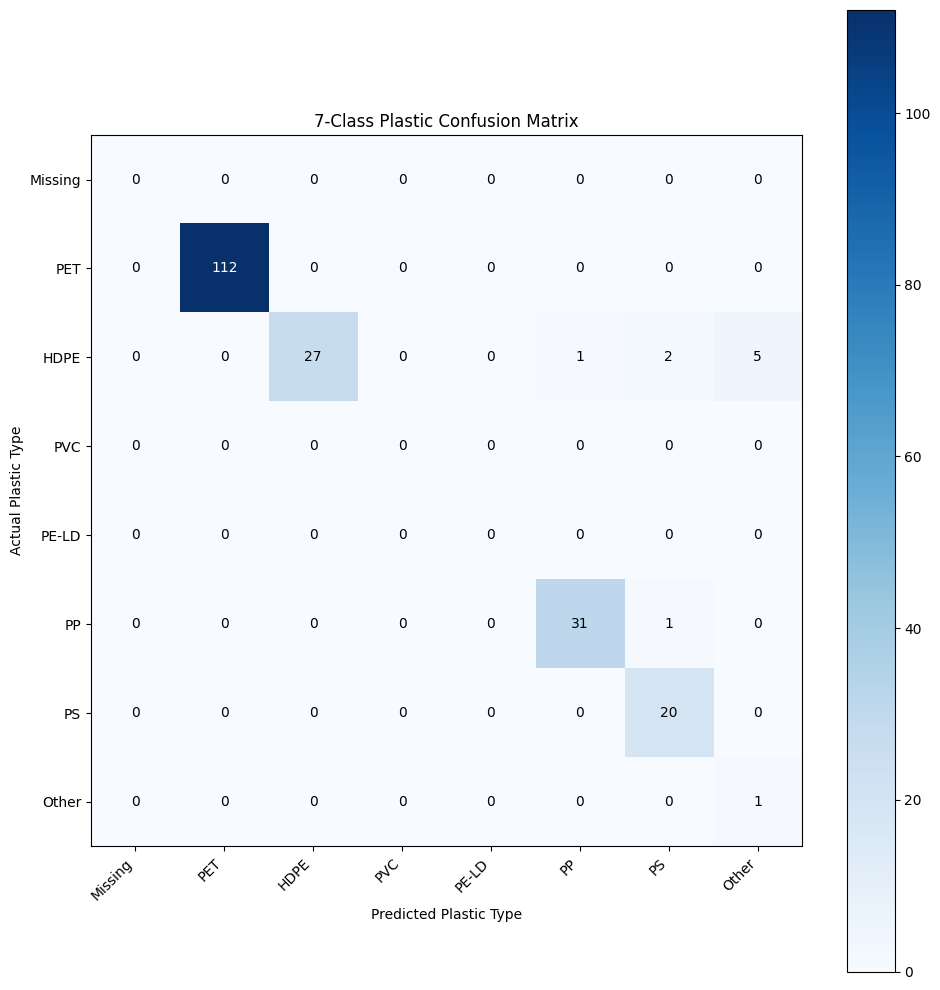

In [32]:
#https://docs.pytorch.org/tutorials/intermediate/char_rnn_classification_tutorial.html
def confusion_matrix(model, dataloader, class_names):
    model.eval()
    num_classes = len(class_names)
    conf_matrix = torch.zeros(num_classes, num_classes)
    
    with torch.no_grad():
        for images, labels in dataloader:
            if isinstance(images, list): images = images[0]
            
            images, labels = images.to(cudaDevice), labels.to(cudaDevice)
            
            # outputs will be size [batch, 8]
            outputs = model(images) 
            
            _, preds = torch.max(outputs, 1)
            
            for t, p in zip(labels.view(-1), preds.view(-1)):
                # safety check: ensure labels/preds don't exceed matrix size
                if t < num_classes and p < num_classes:
                    conf_matrix[t.long(), p.long()] += 1

    # --- Plotting ---
    fig, ax = plt.subplots(figsize=(10, 10))
    im = ax.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
    ax.figure.colorbar(im, ax=ax)
    
    ax.set(xticks=torch.arange(num_classes),
           yticks=torch.arange(num_classes),
           xticklabels=class_names, yticklabels=class_names,
           title='7-Class Plastic Confusion Matrix',
           ylabel='Actual Plastic Type',
           xlabel='Predicted Plastic Type')

    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

    for i in range(num_classes):
        for j in range(num_classes):
            ax.text(j, i, int(conf_matrix[i, j].item()),
                    ha="center", va="center", 
                    color="white" if conf_matrix[i, j] > conf_matrix.max()/2 else "black")

    plt.tight_layout()
    plt.savefig('final_confusion_matrix.png', dpi=300)
    plt.show()

plastic_classes = [
    'Missing',      # 0 (a00)
    'PET',          # 1 (a01)
    'HDPE',        # 2 (a02)
    'PVC',          # 3 (a03)
    'PE-LD',        # 4 (a04)
    'PP',           # 5 (a05)
    'PS',           # 6 (a06)
    'Other'         # 7 (a07)
]

confusion_matrix(model, val_loader, plastic_classes)

In [22]:
# check the labels in validation set
from collections import Counter

all_labels = []
for _, label in val_loader:
    all_labels.extend(label.tolist())

print("Labels in Validation Set:", Counter(all_labels))

Labels in Validation Set: Counter({1: 116, 5: 34, 2: 25, 6: 23, 7: 2})
